# Model Predictions and Visualization

This notebook loads trained convCNP models and visualizes predictions on holdout time periods.

For each fold, we:
1. Load the trained model checkpoint
2. Identify the holdout time period for that fold
3. Select one deterministic day from the holdout period
4. Generate predictions for all spatial points
5. Plot side-by-side heatmaps: ERA5 Input | Ground Truth | Predictions | Bias

After processing all folds, the holdout predictions are combined (since holdout periods are non-overlapping) to produce a single unified evaluation with error maps, uncertainty calibration, CRPS, and skill scores.

In [74]:
%pip install -r requirements.txt

  Using cached plotly-6.5.2-py3-none-any.whl.metadata (8.5 kB)
Using cached plotly-6.5.2-py3-none-any.whl (9.9 MB)
  Attempting uninstall: plotly
    Found existing installation: plotly 6.3.1
    Not uninstalling plotly at /layers/paketo-buildpacks_poetry-install/poetry-venv/datascience-python-renku-dependencies-xS3fZVNL-py3.13/lib/python3.13/site-packages, outside environment /home/renku/work/.venv
    Can't uninstall 'plotly'. No files were found to uninstall.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from pathlib import Path
import warnings

import params

params.configure_renku_cuda()

import matplotlib.pyplot as plt
import numpy as np
import properscoring as ps
import torch

import datasets as ds
import inference as inf
import visualization as vis
from metrics import skill_score
from convCNP.training.training_elev import get_fold_holdout_indices, select_holdout_day

In [76]:
device = params.select_device()
print(f'Using device: {device}')

Using device: cuda


## Configuration

Specify the trained model directory to load.

In [77]:
# Path to trained model directory
MODEL_DIR = Path('./trained_models/base-2023-30e-5f-seasonalmlp')

# Default data paths (used as fallback for older checkpoints without saved paths)
DEFAULT_ERA5_MAX_TEMP_GLOB = './datasets/ERA5_Land/max_temperature/*.nc'
DEFAULT_ERA5_GEOPOTENTIAL_GLOB = './datasets/ERA5_Land/geopotential/*.nc'
DEFAULT_METEO_SWISS_MAX_TEMP_GLOB = './datasets/MeteoSwiss/TmaxD_v2.0_swiss.lv95/*.nc'
DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH = './datasets/topo_subset.zarr'

## Load Training Configuration

In [4]:
# Load params and metadata from training
params = params.load_params_json(MODEL_DIR / 'params.json')
metadata = ds.load_metadata_json(MODEL_DIR / 'metadata.json')

# Override data paths from saved params (fall back to defaults for older checkpoints)
ERA5_MAX_TEMP_GLOB = params.ERA5_MAX_TEMP_GLOB or DEFAULT_ERA5_MAX_TEMP_GLOB
ERA5_GEOPOTENTIAL_GLOB = params.ERA5_GEOPOTENTIAL_GLOB or DEFAULT_ERA5_GEOPOTENTIAL_GLOB
METEO_SWISS_MAX_TEMP_GLOB = params.METEO_SWISS_MAX_TEMP_GLOB or DEFAULT_METEO_SWISS_MAX_TEMP_GLOB
HI_RES_TOPOGRAPHY_ZARR_PATH = params.HI_RES_TOPOGRAPHY_ZARR_PATH or DEFAULT_HI_RES_TOPOGRAPHY_ZARR_PATH

print(f"Loaded configuration for run: {params.TRIAL_NAME}")
print(f"  Variable: {params.VARIABLE}")
print(f"  Data year start: {params.DATA_YEAR_START}")
print(f"  N folds: {params.N_FOLDS}")
print(f"  Model: {params.N_CHANNELS} channels, {params.N_BLOCKS} blocks")
print(f"  ERA5 max temp: {ERA5_MAX_TEMP_GLOB}")
print(f"  ERA5 geopotential: {ERA5_GEOPOTENTIAL_GLOB}")
print(f"  MeteoSwiss: {METEO_SWISS_MAX_TEMP_GLOB}")
print(f"  Topography: {HI_RES_TOPOGRAPHY_ZARR_PATH}")

Loaded configuration for run: base-2013+-30epochs-5folds-with-patience
  Variable: tmax
  Data year start: 2014
  N folds: 5
  Model: 128 channels, 6 blocks


## Load Data

In [79]:
# Load ERA5 input data with geopotential
era5_data, _, era5_grid_elevation, era5_times = ds.load_era5_data(
    ERA5_MAX_TEMP_GLOB,
    var_name='t2m_max',
    year_start=params.DATA_YEAR_START,
    geopotential_glob=ERA5_GEOPOTENTIAL_GLOB,
    device=device
)

print(f"ERA5 data shape: {era5_data.shape}")
print(f"Time coordinates: {len(era5_times)} dates from {era5_times[0]} to {era5_times[-1]}")

# Compute seasonal features from time coordinates if the model was trained with them
if params.SEASONAL_FEATURES_IN_MLP:
    seasonal_features = ds.compute_seasonal_features(era5_times, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}  # (n_times, 2) for [cos_doy, sin_doy]")
else:
    seasonal_features = None
    print("Seasonal features disabled (model was trained without them)")

# Load high-resolution topography (DEM and TPI)
hi_res_elevation, hi_res_tpi = ds.load_high_res_topography(HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading ERA5 data from: ./datasets/ERA5_Land/max_temperature/*.nc


Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset time range from 2014: 2014-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 3652, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m_max (Kelvin)...
Final tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([3652, 5, 29, 61]), dtype: torch.float32

Loading geopotential data from: ./datasets/ERA5_Land/geopotential/*.nc
Geopotential dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 51, 'longitude': 81})
Geopotential lat range: [44.0000, 49.0000], shape: (51,)
Geopotential lon range: [4.0000, 12.0000], shape: (81,)
ERA5 data lat range: [45.4000, 48.2000], shape: (29,)
ERA5 data lon range: [5.0000, 11.0000], shape: (61,)
✓ ERA5 gri

In [80]:
# Load MeteoSwiss targets with elevation and TPI
target_x, target_y, target_topo = ds.prepare_meteoswiss_targets(
    METEO_SWISS_MAX_TEMP_GLOB,
    normalization_stats=metadata,
    data_var='TmaxD',
    grid_elevation=era5_grid_elevation,
    hi_res_elevation=hi_res_elevation,
    hi_res_tpi=hi_res_tpi,
    convert_to_kelvin=True,
    year_start=params.DATA_YEAR_START,
    device=device,
)

# Convert to tensors
target_y_tensor = torch.from_numpy(target_y.values.astype(np.float32)).to(device)
print(f"Target Y shape: {target_y_tensor.shape}")
print(f"Target topo shape: {target_topo.shape}")

# Get grid shape for reshaping predictions
grid_N, grid_E = ds.get_meteoswiss_grid_shape(METEO_SWISS_MAX_TEMP_GLOB)
print(f"MeteoSwiss grid shape: ({grid_N}, {grid_E})")

--- Preparing MeteoSwiss Targets (x, y, e) ---
Flattening (240, 370) grid to (point)...
Creating Target Coordinate Tensor (x)...

=== COORDINATE VERIFICATION ===
MeteoSwiss lat (first 5 points): [45.720608 45.720795 45.720974 45.721157 45.721336]
MeteoSwiss lon (first 5 points): [5.8268523 5.839691  5.8525305 5.86537   5.878209 ]
MeteoSwiss lat range: [45.6886, 47.8820]
MeteoSwiss lon range: [5.7613, 10.6919]

ERA5 normalization bounds (should overlap with MeteoSwiss if both in degrees):
ERA5 lat range: [45.4000, 48.2000]
ERA5 lon range: [5.0000, 11.0000]
=== END COORDINATE VERIFICATION ===

Creating Ground Truth Tensor (y) for TmaxD...
  -> Converting Celsius to Kelvin (+273.15) before normalization
Creating Elevation Tensor (e) [3 features]...
  -> Converting target coordinates to Swiss LV95 for hi-res DEM lookup...
  -> Interpolating hi-res DEM at target points...
  -> Interpolating ERA5 grid elevation at target points...
  -> True elevation range: [181.7, 4675.4] m
  -> Grid elevat

In [81]:
# Calculate distances
dists = ds.calculate_dists_meteoswiss(metadata, target_x, device=device)
print(f"Distances shape: {dists.shape}")

# Elevation tensor is already loaded as target_topo
elev = target_topo
print(f"Elevation tensor shape: {elev.shape}")

Distances shape: torch.Size([88800, 29, 61])
Elevation tensor shape: torch.Size([88800, 3])


In [82]:
# Compute reference predictions: ERA5 bilinearly interpolated to target locations.
# This is a deterministic baseline representing "what ERA5 says at each station".
era5_ref_preds = ds.interpolate_era5_to_targets(era5_data, target_x, metadata)
era5_ref_denorm = metadata.denormalize(era5_ref_preds.cpu().numpy()) - 273.15
print(f"Reference predictions shape: {era5_ref_denorm.shape}  # (time, n_points)")

Reference predictions shape: (3652, 88800)  # (time, n_points)


## Generate Predictions for Each Fold

For each fold, we load the trained model, plot a single representative holdout day, and accumulate predictions over the full holdout period for combined analysis.

Total time samples: 3652
Number of folds: 5
ERA5 grid shape: (29, 61)
MeteoSwiss grid shape: (240, 370)

Fold 1/5
  Loaded model from epoch 26
  Holdout period: days 0 to 729 (730 days)
  Holdout date range: 2014-01-01T00:00:00.000000000 to 2015-12-31T00:00:00.000000000
  Selected day index for single-day plot: 365


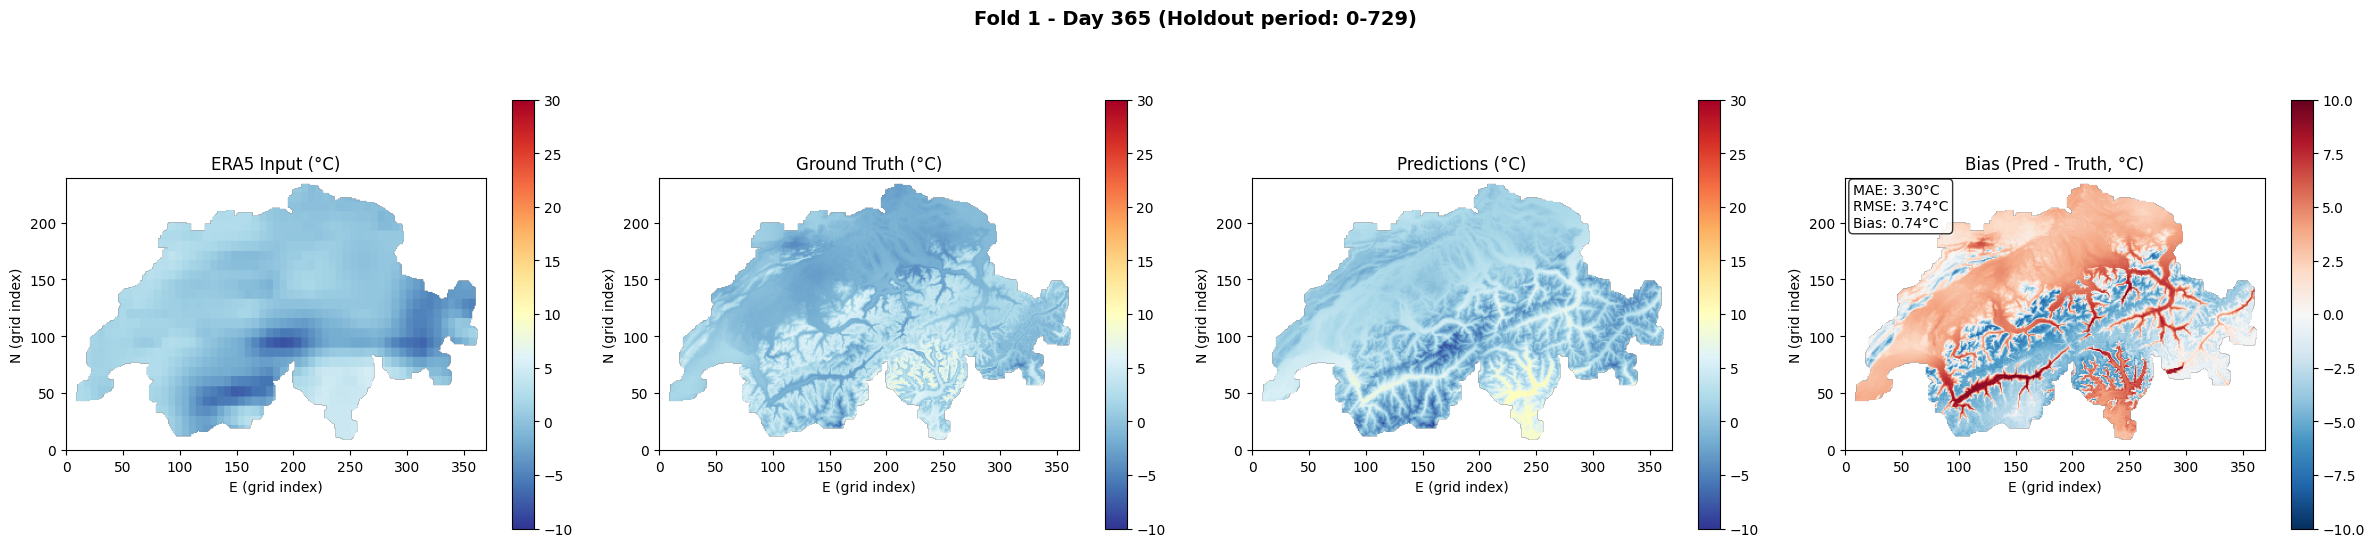

  Computing predictions for all 730 holdout days...
  Fold 1 done: accumulated 730 days

Fold 2/5
  Loaded model from epoch 29
  Holdout period: days 730 to 1459 (730 days)
  Holdout date range: 2016-01-01T00:00:00.000000000 to 2017-12-30T00:00:00.000000000
  Selected day index for single-day plot: 1095


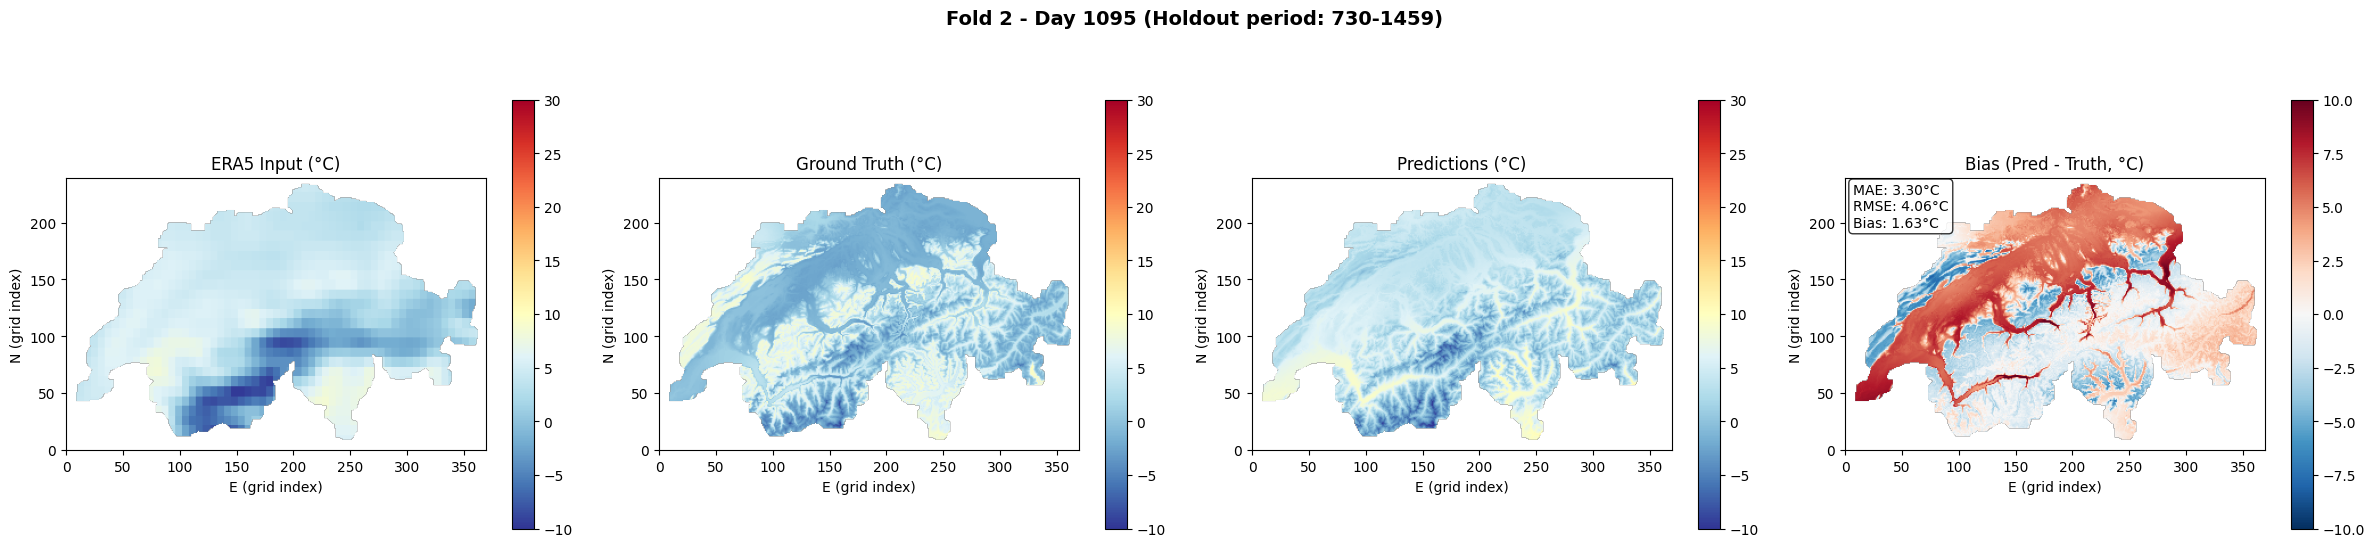

  Computing predictions for all 730 holdout days...
  Fold 2 done: accumulated 730 days

Fold 3/5
  Loaded model from epoch 28
  Holdout period: days 1460 to 2189 (730 days)
  Holdout date range: 2017-12-31T00:00:00.000000000 to 2019-12-30T00:00:00.000000000
  Selected day index for single-day plot: 1825


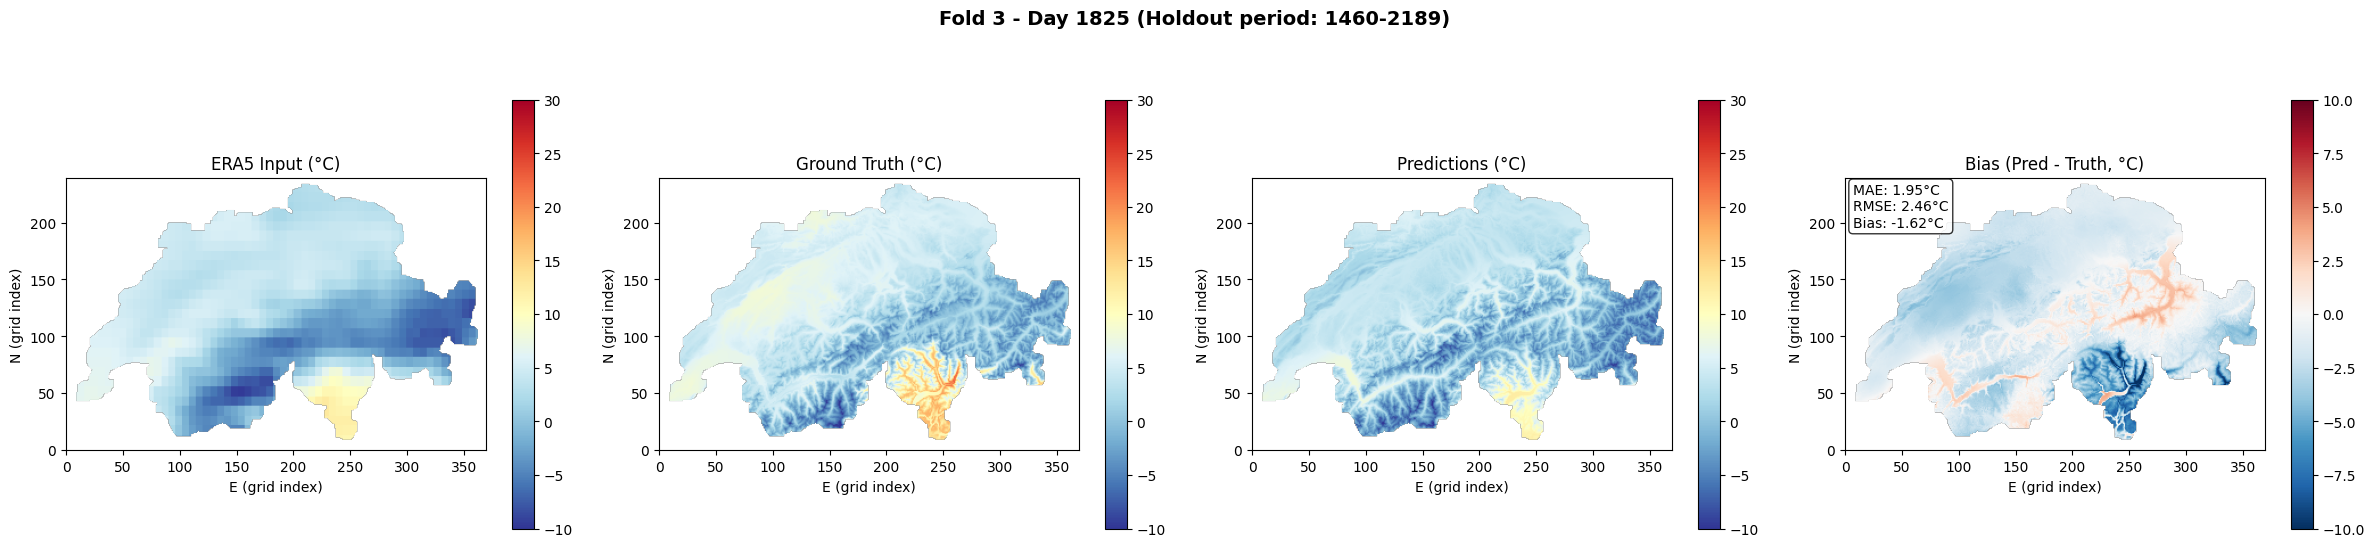

  Computing predictions for all 730 holdout days...
  Fold 3 done: accumulated 730 days

Fold 4/5
  Loaded model from epoch 27
  Holdout period: days 2190 to 2919 (730 days)
  Holdout date range: 2019-12-31T00:00:00.000000000 to 2021-12-29T00:00:00.000000000
  Selected day index for single-day plot: 2555


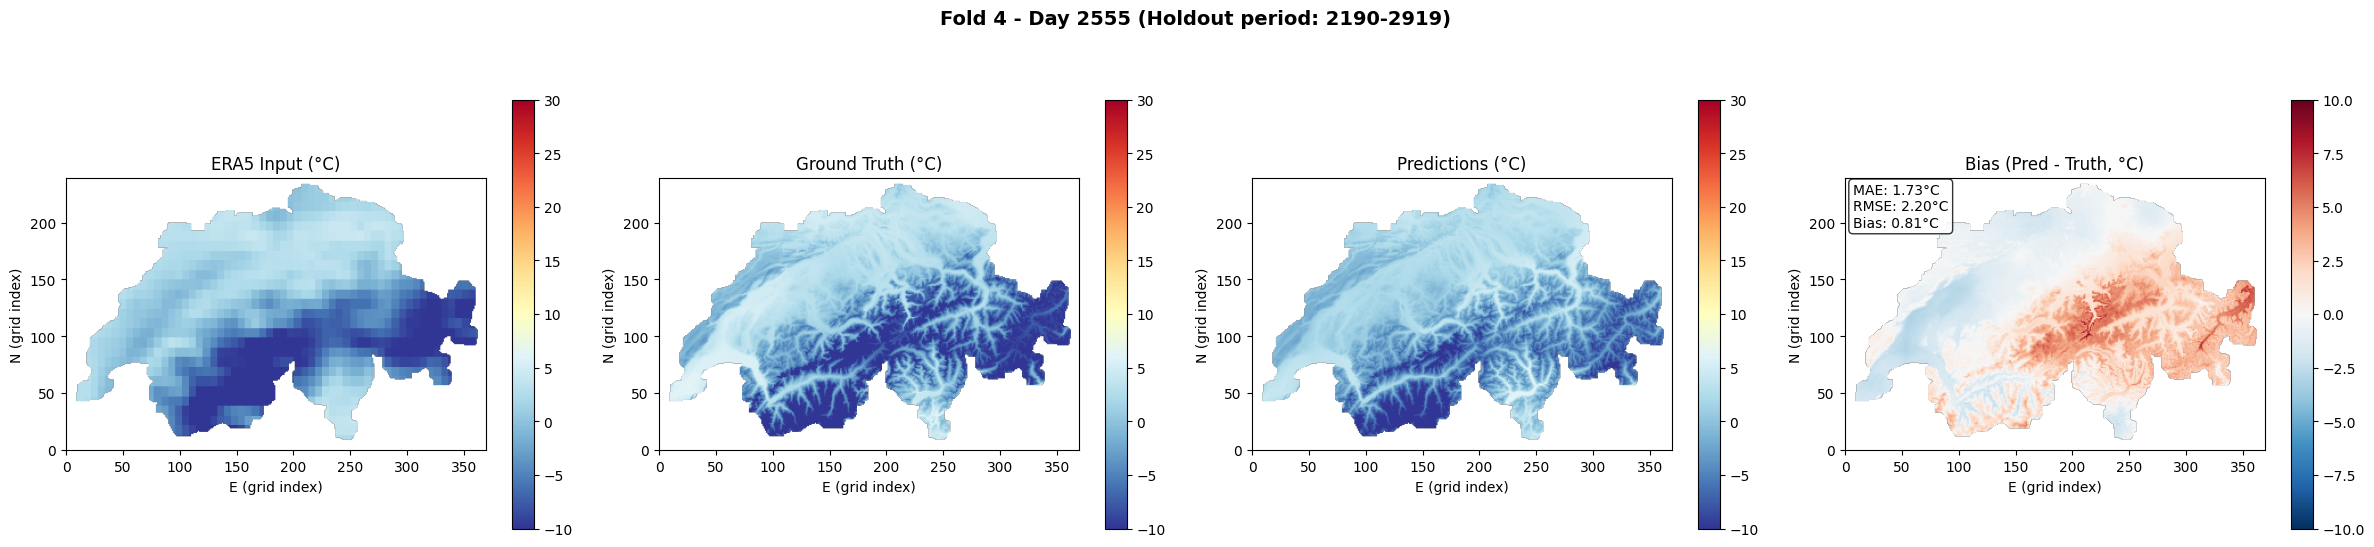

  Computing predictions for all 730 holdout days...
  Fold 4 done: accumulated 730 days

Fold 5/5
  Loaded model from epoch 28
  Holdout period: days 2920 to 3651 (732 days)
  Holdout date range: 2021-12-30T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
  Selected day index for single-day plot: 3286


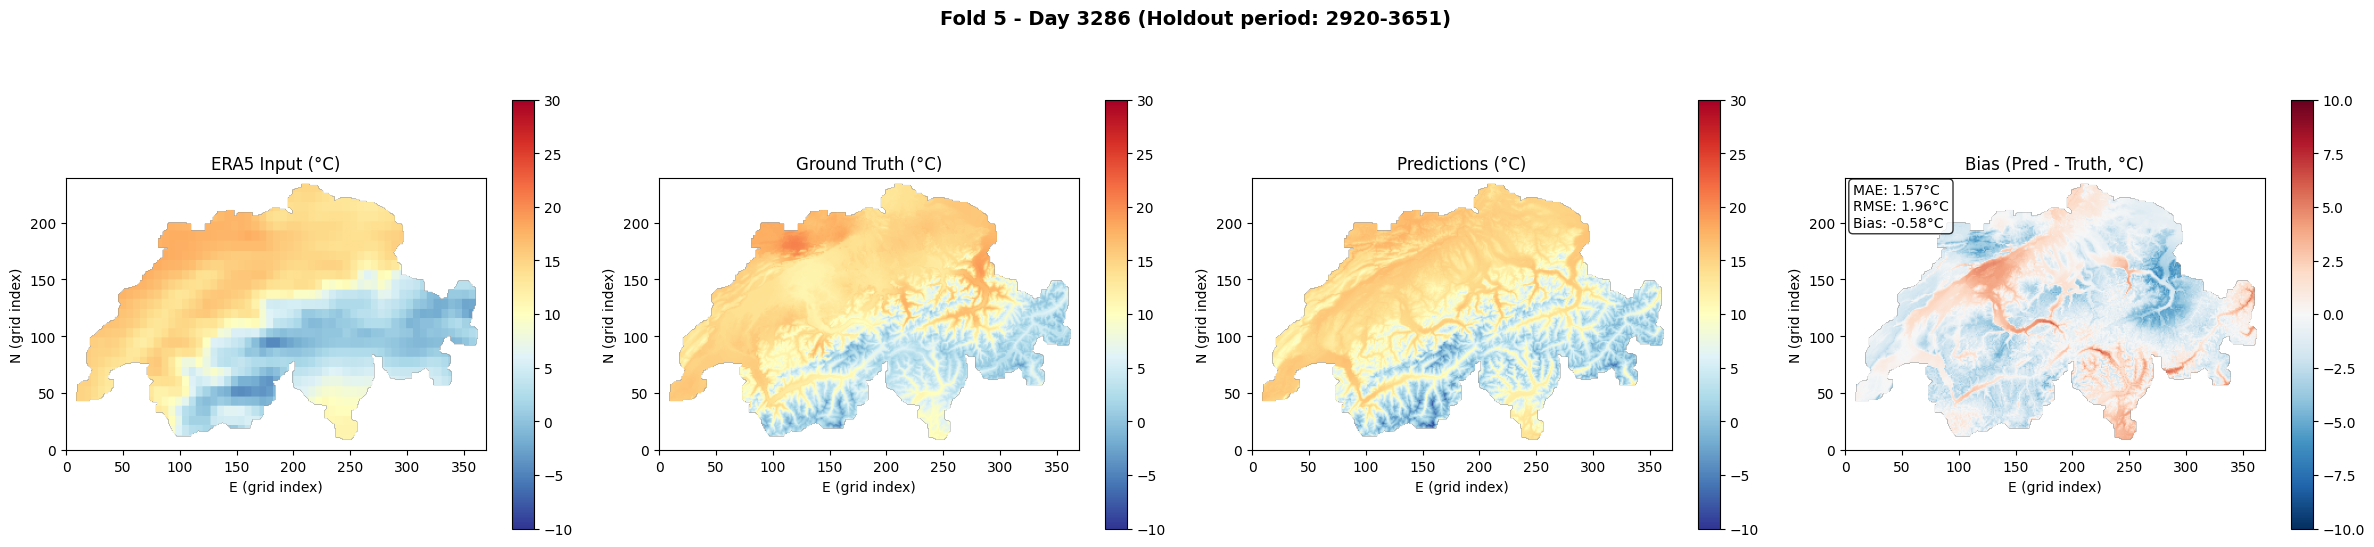

  Computing predictions for all 732 holdout days...
  Fold 5 done: accumulated 732 days

Combined holdout data: 3652 days x 88800 points


In [89]:
n_samples = era5_data.shape[0]
grid_shape = (grid_N, grid_E)
era5_shape = (era5_data.shape[2], era5_data.shape[3])  # (lat, lon)
N, E = grid_shape

print(f"Total time samples: {n_samples}")
print(f"Number of folds: {params.N_FOLDS}")
print(f"ERA5 grid shape: {era5_shape}")
print(f"MeteoSwiss grid shape: {grid_shape}")
print()

# Extract elevation and mTPI grids (these are static, same for all folds)
# elev tensor has shape (n_points, 3): [true_elev, elev_diff, mtpi]
elev_np = elev.cpu().numpy()
true_elev_grid = elev_np[:, 0].reshape(N, E)  # True elevation in meters
mtpi_grid = elev_np[:, 2].reshape(N, E)  # mTPI in meters

# Accumulators for combined holdout analysis
combined_errors = []       # List of (holdout_days_i, n_points) arrays
combined_preds = []        # Denormalized predictions (°C)
combined_sigmas = []       # Predicted sigma
combined_truths = []       # Denormalized ground truth (°C)
combined_dates = []        # Holdout dates for temporal analysis
combined_ref_preds = []    # ERA5 reference predictions for skill score

for fold in range(params.N_FOLDS):
    print(f"={'=' * 59}")
    print(f"Fold {fold + 1}/{params.N_FOLDS}")
    print(f"={'=' * 59}")
    
    # Load model checkpoint
    checkpoint_path = MODEL_DIR / f'model_fold_{fold}'
    if not checkpoint_path.exists():
        print(f"  Checkpoint not found: {checkpoint_path}")
        continue
    
    model, epoch = inf.load_model_checkpoint(checkpoint_path, params, device)
    print(f"  Loaded model from epoch {epoch}")
    
    # Get holdout period for this fold
    holdout_start, holdout_end = get_fold_holdout_indices(fold, params.N_FOLDS, n_samples)
    holdout_days = holdout_end - holdout_start
    holdout_dates = era5_times[holdout_start:holdout_end]
    print(f"  Holdout period: days {holdout_start} to {holdout_end-1} ({holdout_days} days)")
    print(f"  Holdout date range: {holdout_dates[0]} to {holdout_dates[-1]}")
    
    # Select one day from holdout for the single-day visualization
    day_idx = select_holdout_day(fold, holdout_start, holdout_end, seed=params.SEED)
    print(f"  Selected day index for single-day plot: {day_idx}")
    
    # Generate predictions for single day visualization
    predictions, sigma = inf.predict_single_day(model, era5_data, day_idx, dists, elev, seasonal_features, device)
    predictions_np = predictions.cpu().numpy()
    
    # Get ground truth and ERA5 input for single-day plot
    truth = target_y_tensor[day_idx].cpu().numpy()
    era5_temp = era5_data[day_idx, 0].cpu().numpy()
    
    # Plot single-day comparison (kept per fold)
    title = f"Fold {fold + 1} - Day {day_idx} (Holdout period: {holdout_start}-{holdout_end-1})"
    fig = vis.plot_prediction_comparison(
        truth=truth,
        predictions=predictions_np,
        era5_input=era5_temp,
        grid_shape=grid_shape,
        era5_shape=era5_shape,
        metadata=metadata,
        title=title,
        denormalize=True
    )
    plt.show()
    
    # # Plot uncertainty vs error for the single day
    # N, E = grid_shape
    
    # # Denormalize predictions and truth for error calculation
    # pred_denorm = metadata.denormalize(predictions_np) - 273.15
    # truth_denorm = metadata.denormalize(truth) - 273.15
    
   
    # # Calculate absolute error
    # abs_error = np.abs(pred_denorm - truth_denorm)
    
    # # Reshape to grid
    # sigma_grid = sigma_np.reshape(N, E)
    # abs_error_grid = abs_error.reshape(N, E)
    
    # # Apply valid mask
    # sample_truth = truth.reshape(N, E)
    # valid_mask = ~np.isnan(sample_truth)
    # sigma_grid = np.where(valid_mask, sigma_grid, np.nan)
    # abs_error_grid = np.where(valid_mask, abs_error_grid, np.nan)
    
    # # Compute max observed values for plot ranges
    # max_sigma = np.nanmax(sigma_grid)
    # max_error = np.nanmax(abs_error_grid)
    
    # # Plot uncertainty vs error
    # uncertainty_title = f"Fold {fold + 1} - Day {day_idx}: Uncertainty vs Error"
    # fig_uncertainty = vis.plot_uncertainty_vs_error(
    #     sigma_grid=sigma_grid,
    #     abs_error_grid=abs_error_grid,
    #     title=uncertainty_title,
    #     sigma_range=(0, max_sigma),
    #     error_range=(0, max_error)
    # )
    # plt.show()
    
    # Compute predictions for all holdout days and accumulate
    print(f"  Computing predictions for all {holdout_days} holdout days...")
    
    fold_errors = []
    fold_preds = []
    fold_sigmas = []
    fold_truths = []
    
    for holdout_day_idx in range(holdout_start, holdout_end):
        day_preds, day_sigmas = inf.predict_single_day(model, era5_data, holdout_day_idx, dists, elev, seasonal_features, device)
        day_preds_np = day_preds.cpu().numpy()
        day_sigmas_np = day_sigmas.cpu().numpy()
        day_truth = target_y_tensor[holdout_day_idx].cpu().numpy()
        
        # Denormalize to Celsius
        day_preds_denorm = metadata.denormalize(day_preds_np) - 273.15
        day_truth_denorm = metadata.denormalize(day_truth) - 273.15
        
        fold_errors.append(day_preds_denorm - day_truth_denorm)
        fold_preds.append(day_preds_denorm)
        fold_sigmas.append(day_sigmas_np)
        fold_truths.append(day_truth_denorm)
    
    # Stack this fold's arrays: (holdout_days, n_points)
    fold_errors = np.stack(fold_errors, axis=0)
    fold_preds = np.stack(fold_preds, axis=0)
    fold_sigmas = np.stack(fold_sigmas, axis=0)
    fold_truths = np.stack(fold_truths, axis=0)
    
    # Accumulate across folds
    combined_errors.append(fold_errors)
    combined_preds.append(fold_preds)
    combined_sigmas.append(fold_sigmas)
    combined_truths.append(fold_truths)
    combined_dates.append(holdout_dates)
    combined_ref_preds.append(era5_ref_denorm[holdout_start:holdout_end])
    
    print(f"  Fold {fold + 1} done: accumulated {fold_errors.shape[0]} days")
    print()

# Concatenate all folds along time axis
all_errors = np.concatenate(combined_errors, axis=0)
all_preds_denorm = np.concatenate(combined_preds, axis=0)
all_sigmas = np.concatenate(combined_sigmas, axis=0)
all_truths_denorm = np.concatenate(combined_truths, axis=0)
all_holdout_dates = np.concatenate(combined_dates, axis=0)
all_ref_preds = np.concatenate(combined_ref_preds, axis=0)

print(f"Combined holdout data: {all_errors.shape[0]} days x {all_errors.shape[1]} points")

## Combined Holdout Analysis (All Folds)

The following plots use the concatenated holdout predictions from all folds, covering the entire year.

Computing combined metrics over 3652 holdout days from 5 folds
Overall CRPS: 1.257°C
Global skill score: 0.505
Overall MAE: 1.368°C
Overall RMSE: 1.788°C
Overall Bias: -0.004°C


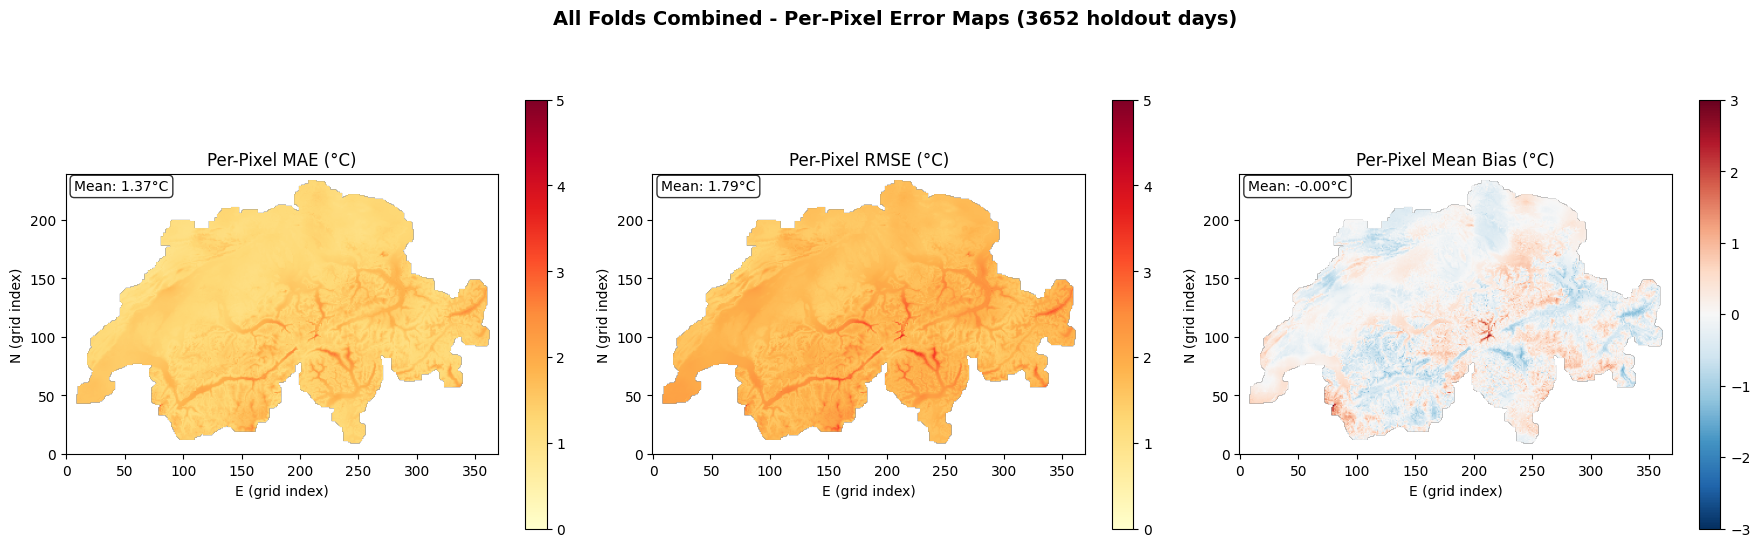

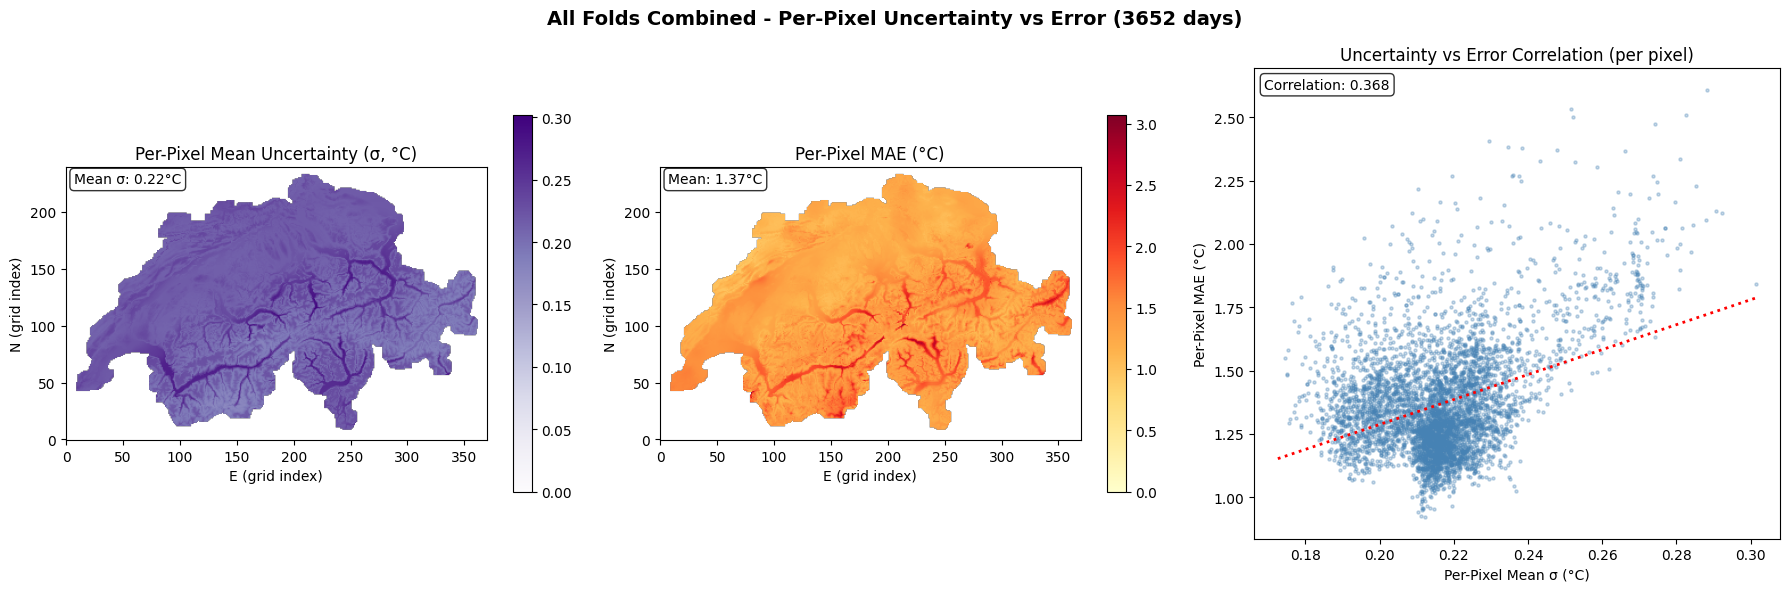

Per-pixel uncertainty-error correlation: 0.368


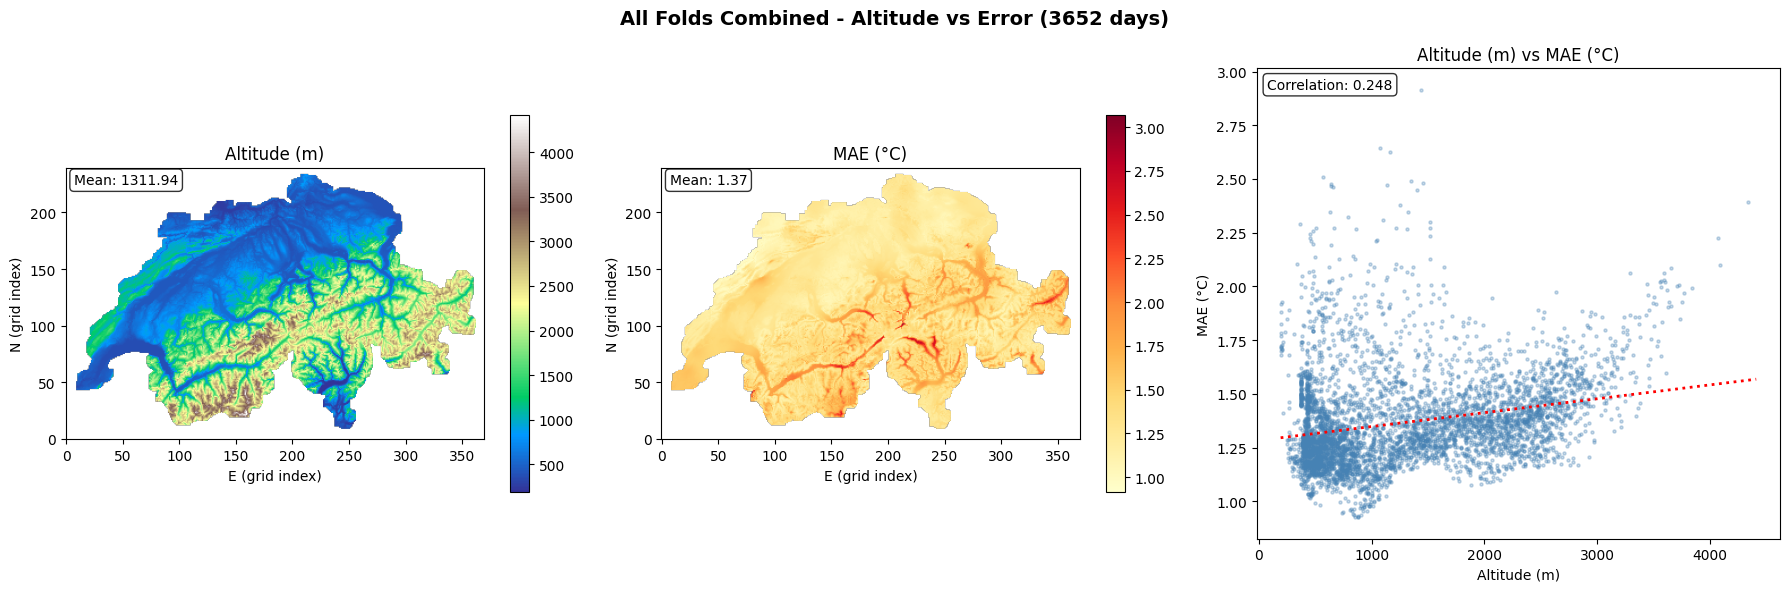

Altitude-error correlation: 0.248


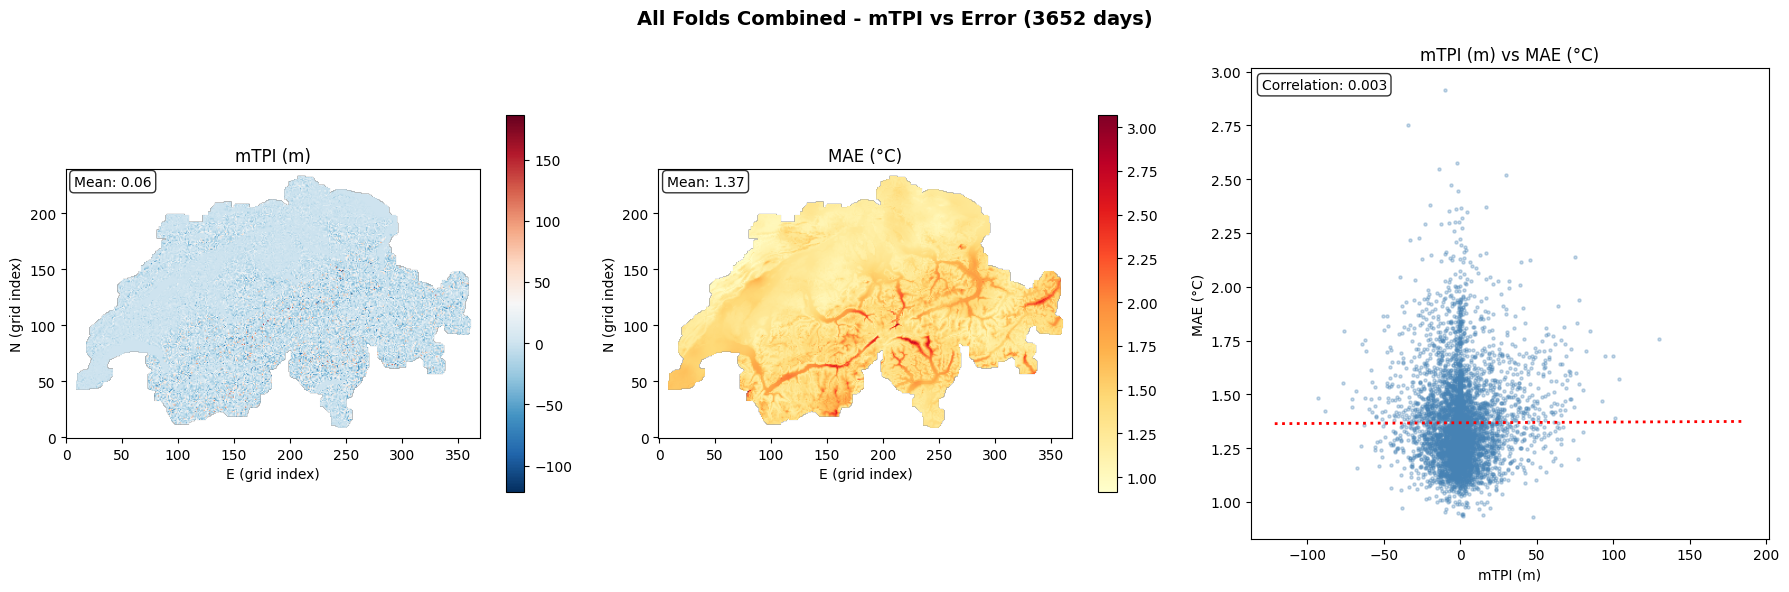

mTPI-error correlation: 0.003


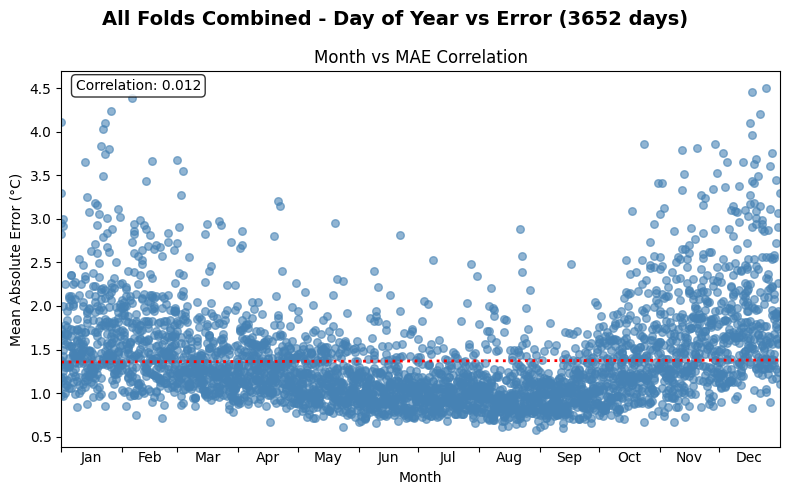

Day of year-error correlation: 0.012


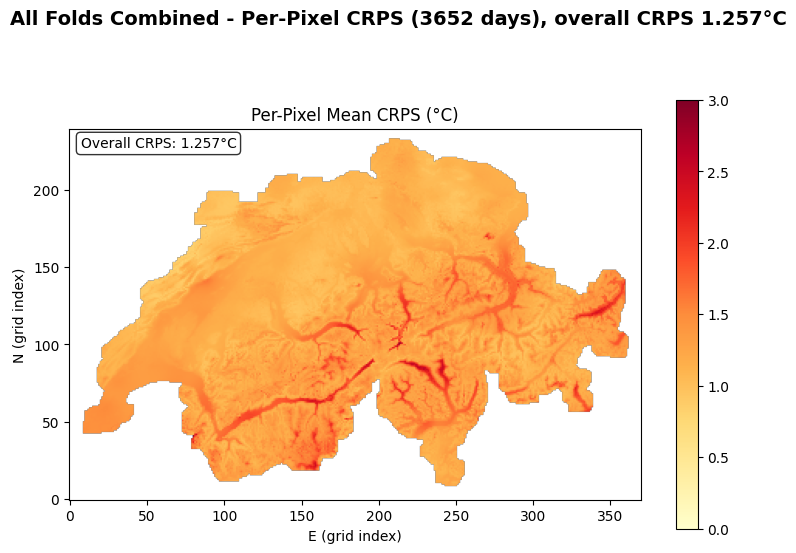

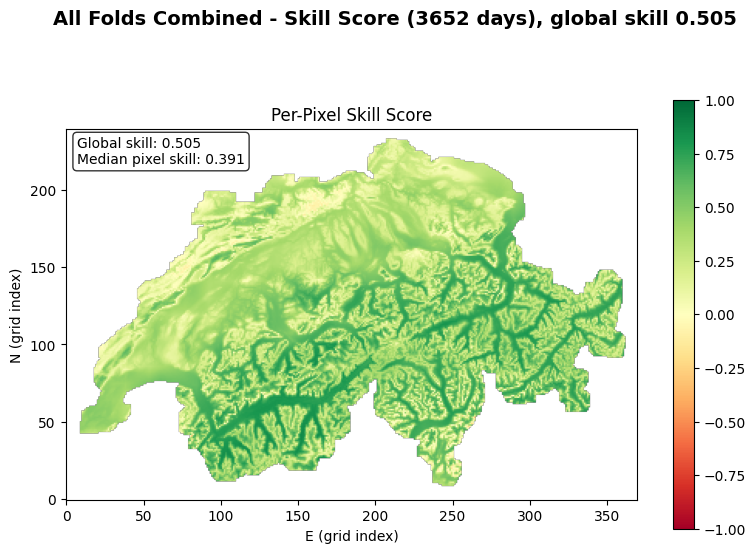

In [ ]:
# --- Per-pixel metrics across all folds ---
total_days = all_errors.shape[0]
print(f"Computing combined metrics over {total_days} holdout days from {params.N_FOLDS} folds")

# Suppress "Mean of empty slice" warnings from pixels outside the valid MeteoSwiss mask
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)

    # Per-pixel MAE, RMSE, bias, mean sigma
    mae_per_pixel = np.nanmean(np.abs(all_errors), axis=0)
    rmse_per_pixel = np.sqrt(np.nanmean(all_errors ** 2, axis=0))
    bias_per_pixel = np.nanmean(all_errors, axis=0)
    mean_sigma_per_pixel = np.nanmean(all_sigmas, axis=0)

    # CRPS (Gaussian predictions vs observations)
    crps_all = ps.crps_gaussian(all_truths_denorm, mu=all_preds_denorm, sig=all_sigmas)
    crps_per_pixel = np.nanmean(crps_all, axis=0)
    overall_crps = np.nanmean(crps_all)

    # Reference CRPS (deterministic ERA5 interpolation: CRPS = |pred - obs|)
    crps_ref_all = np.abs(all_ref_preds - all_truths_denorm)
    crps_ref_per_pixel = np.nanmean(crps_ref_all, axis=0)

print(f"Overall CRPS: {overall_crps:.3f}°C")

# Global skill score
global_skill = metrics.skill_score(np.nanmean(crps_all), np.nanmean(crps_ref_all))
print(f"Global skill score: {global_skill:.3f}")

# Overall MAE and RMSE
print(f"Overall MAE: {np.nanmean(mae_per_pixel):.3f}°C")
print(f"Overall RMSE: {np.nanmean(rmse_per_pixel):.3f}°C")
print(f"Overall Bias: {np.nanmean(bias_per_pixel):.3f}°C")

# Reshape to grids and apply valid mask
sample_truth = target_y_tensor[0].cpu().numpy().reshape(N, E)
valid_mask = ~np.isnan(sample_truth)

mae_grid = np.where(valid_mask, mae_per_pixel.reshape(N, E), np.nan)
rmse_grid = np.where(valid_mask, rmse_per_pixel.reshape(N, E), np.nan)
bias_grid = np.where(valid_mask, bias_per_pixel.reshape(N, E), np.nan)
crps_grid = np.where(valid_mask, crps_per_pixel.reshape(N, E), np.nan)
mean_sigma_grid = np.where(valid_mask, mean_sigma_per_pixel.reshape(N, E), np.nan)
true_elev_grid_masked = np.where(valid_mask, true_elev_grid, np.nan)
mtpi_grid_masked = np.where(valid_mask, mtpi_grid, np.nan)

# Per-pixel skill score
skill_per_pixel = 1.0 - (crps_per_pixel / crps_ref_per_pixel)
skill_grid = np.where(valid_mask, skill_per_pixel.reshape(N, E), np.nan)

# --- Plots ---

# 1. Error maps
fig_errors = vis.plot_error_maps(
    mae_grid=mae_grid, rmse_grid=rmse_grid, bias_grid=bias_grid,
    title=f"All Folds Combined - Per-Pixel Error Maps ({total_days} holdout days)",
    error_range=(0, 5), bias_range=(-3, 3)
)
plt.show()

# 2. Per-pixel uncertainty vs error
fig_unc, perpixel_corr = vis.plot_perpixel_uncertainty_vs_error(
    mean_sigma_grid=mean_sigma_grid, mae_grid=mae_grid,
    title=f"All Folds Combined - Per-Pixel Uncertainty vs Error ({total_days} days)",
    sigma_range=(0, np.nanmax(mean_sigma_grid)),
    error_range=(0, np.nanmax(mae_grid))
)
plt.show()
print(f"Per-pixel uncertainty-error correlation: {perpixel_corr:.3f}")

# 3. Altitude vs error
fig_alt, alt_corr = vis.plot_perpixel_correlation(
    x_grid=true_elev_grid_masked, y_grid=mae_grid,
    x_label='Altitude (m)', y_label='MAE (°C)',
    title=f"All Folds Combined - Altitude vs Error ({total_days} days)",
    x_cmap='terrain', y_cmap='YlOrRd'
)
plt.show()
print(f"Altitude-error correlation: {alt_corr:.3f}")

# 4. mTPI vs error
fig_mtpi, mtpi_corr = vis.plot_perpixel_correlation(
    x_grid=mtpi_grid_masked, y_grid=mae_grid,
    x_label='mTPI (m)', y_label='MAE (°C)',
    title=f"All Folds Combined - mTPI vs Error ({total_days} days)",
    x_cmap='RdBu_r', y_cmap='YlOrRd'
)
plt.show()
print(f"mTPI-error correlation: {mtpi_corr:.3f}")

# 5. Day of year vs error
fig_doy, doy_corr = vis.plot_temporal_error_analysis(
    all_errors=all_errors, holdout_dates=all_holdout_dates,
    title=f"All Folds Combined - Day of Year vs Error ({total_days} days)"
)
plt.show()
print(f"Day of year-error correlation: {doy_corr:.3f}")

# 6. CRPS map
fig_crps, _ = vis.plot_crps_map(
    crps_grid=crps_grid,
    title=f"All Folds Combined - Per-Pixel CRPS ({total_days} days), overall CRPS {overall_crps:.3f}°C",
    crps_range=(0, 3)
)
plt.show()

# 7. Skill score map
fig_skill = vis.plot_skill_map(
    skill_grid=skill_grid, global_skill=global_skill,
    title=f"All Folds Combined - Skill Score ({total_days} days), global skill {global_skill:.3f}"
)
plt.show()

## Summary

This notebook demonstrates how to:
1. Load trained convCNP models using saved configuration (one per fold)
2. Reconstruct the holdout time periods used during cross-validation
3. Generate spatial predictions for the entire MeteoSwiss grid
4. **Per-fold:** Visualize a single representative day showing ERA5 input, ground truth, predictions, and bias
   The residual maps show where the model performs well (white) and where it struggles (blue=lower predictions, red=higher predictions).
5. **Combined across all folds:** Since holdout periods are non-overlapping, predictions from all folds are concatenated to produce a unified evaluation covering the entire year:
   - Per-pixel error maps (MAE, RMSE, bias)
   - Uncertainty calibration (predicted σ vs actual MAE)
   - Error correlations with altitude and mTPI
   - Temporal error patterns (day-of-year analysis)
   - CRPS (Continuous Ranked Probability Score) for probabilistic calibration
   - Skill score relative to ERA5 bilinear interpolation baseline

### Interpretation of correlation plots:
- **Uncertainty vs Error:** High correlation indicates good calibration - the model "knows where it doesn't know"
- **Altitude vs Error:** Positive correlation suggests the model struggles more at high elevations
- **mTPI vs Error:** Positive values = ridges, negative = valleys. Correlation reveals terrain-dependent biases
- **Day of Year vs Error:** Reveals seasonal performance variations across the holdout period